<div style="text-align: center; margin-top: 200px; margin-bottom: 100px;">

# Machine Learning for Data Analytics  
## Assignment 6

<br><br>

**Piotr Czech, Filip Miśkiewicz**

</div>

In [1]:
%%html
<style>
img {
    max-width: 1050px !important;
    margin: 20px auto !important;
    display: block !important;
    border: 2px solid #ccc !important;
    padding: 60px 30px !important;
}
</style>

In [2]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import copy
import random
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

from IPython.display import display
from PIL import Image
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from torchvision.models import ResNet50_Weights

warnings.filterwarnings('ignore')

In [3]:
random_state = 333

# Reproducibility
torch.manual_seed(random_state)
np.random.seed(random_state)
random.seed(random_state)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(random_state)
    torch.backends.cudnn.benchmark = True

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Table of Contents

* [Problem 6.1: Transfer Learning](#problem-61-transfer-learning)
* [Problem 6.2: Few-Shot Learning](#problem-62-few-shot-learning)

## Problem 6.1: Transfer Learning

### Objective
Fine-tune pre-trained models

### Tasks
- Use ResNet50 pre-trained on ImageNet.
- Fine-tune on a small custom image dataset (e.g., Cats vs. Dogs with 500 samples per class).
- Experiment with freezing different numbers of layers.
- Compare with training from scratch.

In this exercise we use transfer learning for a small cats vs dogs classifier. The main idea is simple: instead of training a deep model from zero, we start from ResNet50 trained on ImageNet and adapt it to our two classes. ResNet50 has about 25.5 million parameters and was trained on around 1.2 million images from 1000 classes. Because of that, the early and middle layers already know useful visual features like edges, textures, shapes, and object parts.

The basic structure is:

`input image -> ... -> layer1 -> layer2 -> layer3 -> layer4 -> fc`

For our task we replace the original `fc` layer with a new layer for 2 classes: cats and dogs.

The cats vs dogs dataset is already prepared in a simple folder structure. We only check how many images are in every split. Original Kaggle source: `curl -L -o ./dogs-cats-images.zip https://www.kaggle.com/api/v1/datasets/download/chetankv/dogs-cats-images`.

In [4]:
data_root = Path('./../datasets/dogs-cats-images')
classes = ['cats', 'dogs']
splits = ['train', 'validation', 'test']

rows = []
for split in splits:
    for class_name in classes:
        folder = data_root / split / class_name
        rows.append({
            'split': split,
            'class': class_name,
            'images': len(list(folder.glob('*.jpg'))),
        })

counts_df = pd.DataFrame(rows)
display(counts_df)

,split,class,images
0,train,cats,500
1,train,dogs,500
2,validation,cats,250
3,validation,dogs,250
4,test,cats,250
5,test,dogs,250


now lets preview a few images from each split

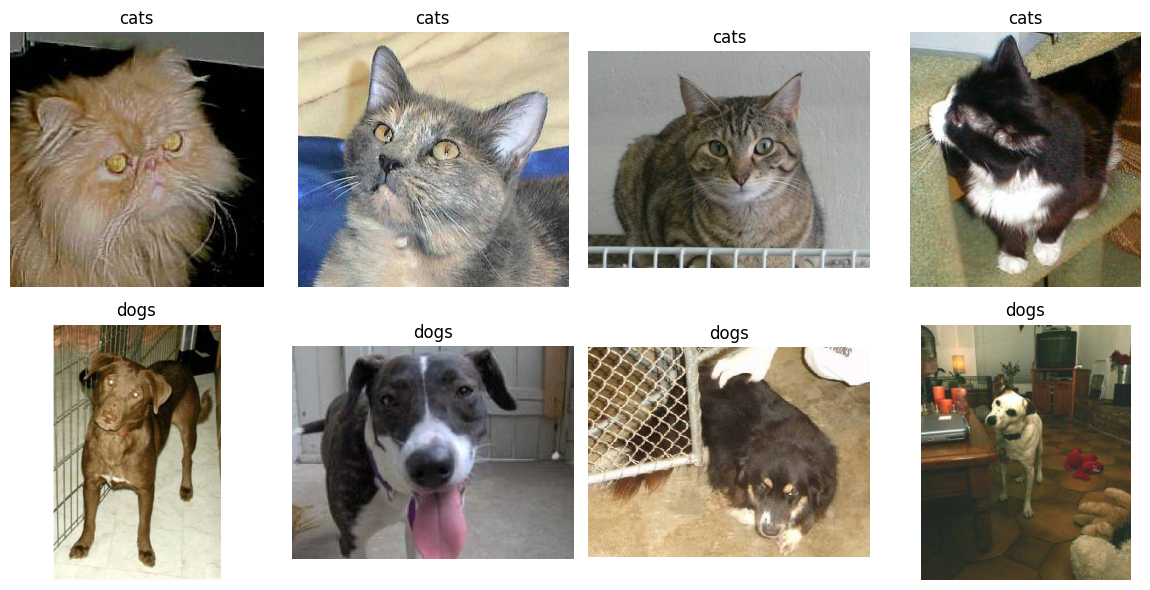

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for row_idx, class_name in enumerate(classes):
    image_paths = sorted((data_root / 'train' / class_name).glob('*.jpg'))[:4]
    for col_idx, image_path in enumerate(image_paths):
        image = Image.open(image_path).convert('RGB')
        axes[row_idx, col_idx].imshow(image)
        axes[row_idx, col_idx].set_title(class_name)
        axes[row_idx, col_idx].axis('off')
plt.tight_layout()
plt.show()

ResNet50 expects images normalized like ImageNet images. We also resize images to a fixed size.

For training we add simple augmentation. This means that the model does not always see exactly the same picture. Sometimes it sees a different crop or mirrored version, but the label is still the same.

In [6]:
image_size = 160 if device.type == 'cpu' else 224
batch_size = 16 if device.type == 'cpu' else 32
num_workers = 2 if os.cpu_count() and os.cpu_count() > 2 else 0

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(image_size, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

eval_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

image_datasets = {
    'train': datasets.ImageFolder(data_root / 'train', transform=train_transform),
    'validation': datasets.ImageFolder(data_root / 'validation', transform=eval_transform),
    'test': datasets.ImageFolder(data_root / 'test', transform=eval_transform),
}

generator = torch.Generator()
generator.manual_seed(random_state)

dataloaders = {
    'train': DataLoader(
        image_datasets['train'],
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        generator=generator,
    ),
    'validation': DataLoader(
        image_datasets['validation'],
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
    ),
    'test': DataLoader(
        image_datasets['test'],
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
    ),
}

class_names = image_datasets['train'].classes
print(f'Classes: {class_names}')
print(f'Image size: {image_size}x{image_size}')
print(f'Batch size: {batch_size}')

images, labels = next(iter(dataloaders['train']))
print(f'One batch shape: {images.shape}')
print(f'Example labels: {labels[:8].tolist()}')

Classes: ['cats', 'dogs']
Image size: 224x224
Batch size: 32


One batch shape: torch.Size([32, 3, 224, 224])
Example labels: [1, 1, 1, 1, 0, 1, 0, 0]


Below we show a small example of this augmentation on one image. The animal is still the same, but the crop and orientation may change a bit.

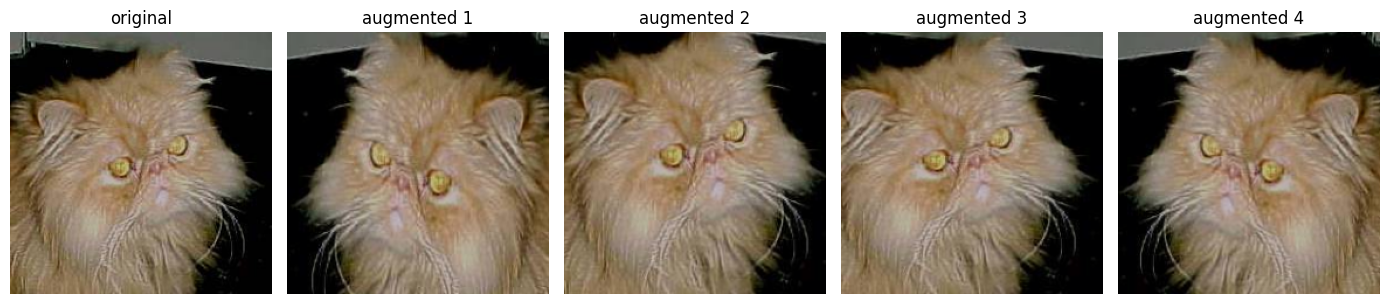

In [7]:
example_image_path = sorted((data_root / 'train' / 'cats').glob('*.jpg'))[0]
example_image = Image.open(example_image_path).convert('RGB')

fig, axes = plt.subplots(1, 5, figsize=(14, 4))
axes[0].imshow(example_image.resize((image_size, image_size)))
axes[0].set_title('original')
axes[0].axis('off')

for idx in range(1, 5):
    augmented = train_transform(example_image)
    augmented = augmented.permute(1, 2, 0).numpy()
    augmented = augmented * np.array(imagenet_std) + np.array(imagenet_mean)
    augmented = np.clip(augmented, 0, 1)

    axes[idx].imshow(augmented)
    axes[idx].set_title(f'augmented {idx}')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

The augmentation example shows that one training image can appear in a few slightly different versions. Some crops are tighter and some images are flipped horizontally. It is still the same class, but model sees more visual variety during training.

We compare several fine-tuning strategies. In every pretrained case the original ImageNet head is replaced with a new `Linear(2048, 2)` layer. The difference between variants is how many ResNet blocks are trainable.

In [8]:
weights = ResNet50_Weights.DEFAULT
criterion = nn.CrossEntropyLoss()

def count_trainable_parameters(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return total, trainable

def build_resnet50_model(config):
    if config['pretrained']:
        model = models.resnet50(weights=weights)
        for param in model.parameters():
            param.requires_grad = False

        model.fc = nn.Linear(model.fc.in_features, 2)

        if config['unfreeze'] in ['layer4', 'layer3_layer4']:
            for param in model.layer4.parameters():
                param.requires_grad = True
        if config['unfreeze'] == 'layer3_layer4':
            for param in model.layer3.parameters():
                param.requires_grad = True
    else:
        model = models.resnet50(weights=None, num_classes=2)

    return model.to(device)

def run_epoch(model, loader, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    all_preds = []
    all_targets = []

    for images, targets in loader:
        images = images.to(device)
        targets = targets.to(device)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            outputs = model(images)
            loss = criterion(outputs, targets)

            if is_training:
                loss.backward()
                optimizer.step()

        preds = outputs.argmax(dim=1)
        total_loss += loss.item() * images.size(0)
        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(targets.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    return avg_loss, acc, np.array(all_targets), np.array(all_preds)

def train_model(config):
    model = build_resnet50_model(config)
    total_params, trainable_params = count_trainable_parameters(model)
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=config['lr'],
        weight_decay=1e-4,
    )

    history = []
    best_val_loss = np.inf
    best_state = None
    started = time.time()

    print(f"Training {config['name']} ({trainable_params:,} trainable params)")
    for epoch in range(1, config['epochs'] + 1):
        train_loss, train_acc, _, _ = run_epoch(model, dataloaders['train'], optimizer)
        val_loss, val_acc, _, _ = run_epoch(model, dataloaders['validation'])

        history.append({
            'epoch': epoch,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_loss': val_loss,
            'val_acc': val_acc,
        })

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"epoch {epoch}: "
            f"train loss={train_loss:.3f}, train acc={train_acc:.3f}, "
            f"val loss={val_loss:.3f}, val acc={val_acc:.3f}"
        )

    model.load_state_dict(best_state)
    test_loss, test_acc, y_true, y_pred = run_epoch(model, dataloaders['test'])
    test_f1 = f1_score(y_true, y_pred)
    elapsed = time.time() - started

    result = {
        'model': config['name'],
        'total_params': total_params,
        'trainable_params': trainable_params,
        'best_val_loss': min(row['val_loss'] for row in history),
        'best_val_acc': max(row['val_acc'] for row in history),
        'test_loss': test_loss,
        'test_acc': test_acc,
        'test_f1': test_f1,
        'time_sec': elapsed,
    }

    return model, pd.DataFrame(history), result, y_true, y_pred

Before running all experiments, we check if a ResNet50 forward pass works correctly for our batch shape.

In [9]:
dry_model = models.resnet50(weights=None, num_classes=2).to(device)
dry_model.eval()
with torch.no_grad():
    dry_outputs = dry_model(images[:2].to(device))
print(f'Dry forward output shape: {dry_outputs.shape}')
del dry_model

Dry forward output shape: torch.Size([2, 2])


Now we run four experiments. On CPU we use fewer epochs to keep the notebook practical, but every case is still trained on the same 1000 training images.

In [10]:
if device.type == 'cpu':
    experiment_configs = [
        {'name': 'head_only', 'pretrained': True, 'unfreeze': 'fc', 'epochs': 2, 'lr': 1e-3},
        {'name': 'layer4_fc', 'pretrained': True, 'unfreeze': 'layer4', 'epochs': 1, 'lr': 1e-4},
        {'name': 'layer3_layer4_fc', 'pretrained': True, 'unfreeze': 'layer3_layer4', 'epochs': 1, 'lr': 5e-5},
        {'name': 'scratch', 'pretrained': False, 'unfreeze': 'all', 'epochs': 1, 'lr': 3e-4},
    ]
else:
    experiment_configs = [
        {'name': 'head_only', 'pretrained': True, 'unfreeze': 'fc', 'epochs': 3, 'lr': 1e-3},
        {'name': 'layer4_fc', 'pretrained': True, 'unfreeze': 'layer4', 'epochs': 3, 'lr': 1e-4},
        {'name': 'layer3_layer4_fc', 'pretrained': True, 'unfreeze': 'layer3_layer4', 'epochs': 3, 'lr': 5e-5},
        {'name': 'scratch', 'pretrained': False, 'unfreeze': 'all', 'epochs': 3, 'lr': 3e-4},
    ]

histories = {}
results = []
test_predictions = {}
best_model_state = None
best_model_config = None
best_test_acc = -1

for config in experiment_configs:
    model, history, result, y_true, y_pred = train_model(config)
    histories[config['name']] = history
    results.append(result)
    test_predictions[config['name']] = (y_true, y_pred)

    if result['test_acc'] > best_test_acc:
        best_test_acc = result['test_acc']
        best_model_config = config.copy()
        best_model_state = copy.deepcopy(model.cpu().state_dict())

    del model
    if device.type == 'cuda':
        torch.cuda.empty_cache()

results_df = pd.DataFrame(results)
results_display = results_df.copy()
for col in ['best_val_loss', 'best_val_acc', 'test_loss', 'test_acc', 'test_f1']:
    results_display[col] = results_display[col].round(3)
results_display['time_min'] = (results_display['time_sec'] / 60).round(2)
results_display = results_display.drop(columns='time_sec')
display(results_display)

Training head_only (4,098 trainable params)


epoch 1: train loss=0.348, train acc=0.890, val loss=0.176, val acc=0.990


epoch 2: train loss=0.138, train acc=0.971, val loss=0.094, val acc=0.986


epoch 3: train loss=0.093, train acc=0.984, val loss=0.069, val acc=0.992


Training layer4_fc (14,968,834 trainable params)


...

Training scratch (23,512,130 trainable params)


epoch 1: train loss=0.883, train acc=0.517, val loss=1.378, val acc=0.500


epoch 2: train loss=0.681, train acc=0.604, val loss=1.332, val acc=0.518


epoch 3: train loss=0.695, train acc=0.584, val loss=0.882, val acc=0.504


,model,total_params,trainable_params,best_val_loss,best_val_acc,test_loss,test_acc,test_f1,time_min
0,head_only,23512130,4098,0.069,0.992,0.096,0.982,0.982,0.13
1,layer4_fc,23512130,14968834,0.021,0.998,0.044,0.990,0.990,0.16
2,layer3_layer4_fc,23512130,22067202,0.025,0.998,0.041,0.988,0.988,0.21
3,scratch,23512130,23512130,0.882,0.518,0.877,0.502,0.008,0.36


The table already shows a big difference between pretrained models and training from scratch. `head_only` trains only about 4k parameters and still reaches around `0.98` test accuracy. When we unfreeze `layer4`, test accuracy increases to about `0.99`, so the last ResNet block can adapt a bit better to cats and dogs. Unfreezing also `layer3` gives a very similar result, but it trains much more parameters.

The scratch model is much weaker. It trains all 23.5M parameters, but with only 1000 training images it stays close to random guessing.

now we plot training curves

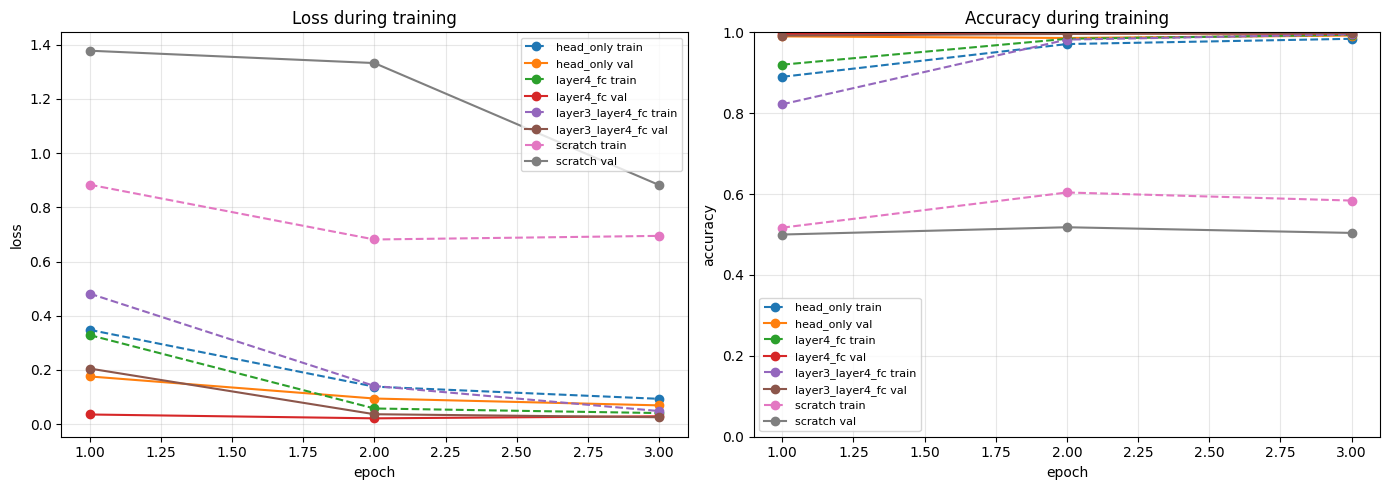

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for model_name, history in histories.items():
    axes[0].plot(history['epoch'], history['train_loss'], marker='o', linestyle='--', label=f'{model_name} train')
    axes[0].plot(history['epoch'], history['val_loss'], marker='o', label=f'{model_name} val')
    axes[1].plot(history['epoch'], history['train_acc'], marker='o', linestyle='--', label=f'{model_name} train')
    axes[1].plot(history['epoch'], history['val_acc'], marker='o', label=f'{model_name} val')

axes[0].set_title('Loss during training')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss')
axes[0].grid(alpha=0.3)
axes[1].set_title('Accuracy during training')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('accuracy')
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 1)
axes[0].legend(fontsize=8)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

On the loss plot we can see that pretrained models quickly go down and keep very low validation loss. The scratch model behaves differently. Its validation accuracy stays around `0.5`, which means it did not really learn a stable cats vs dogs classifier in this short training.

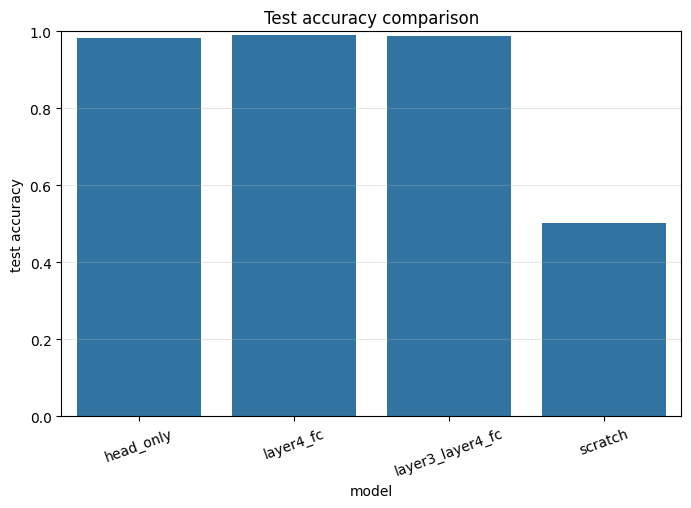

In [12]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x='model', y='test_acc')
plt.title('Test accuracy comparison')
plt.xlabel('model')
plt.ylabel('test accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.grid(axis='y', alpha=0.3)
plt.show()

The barplot makes the comparison very direct. All transfer learning models are near the top of the chart, while the scratch model is close to random classifier level.

and confusion matrices..

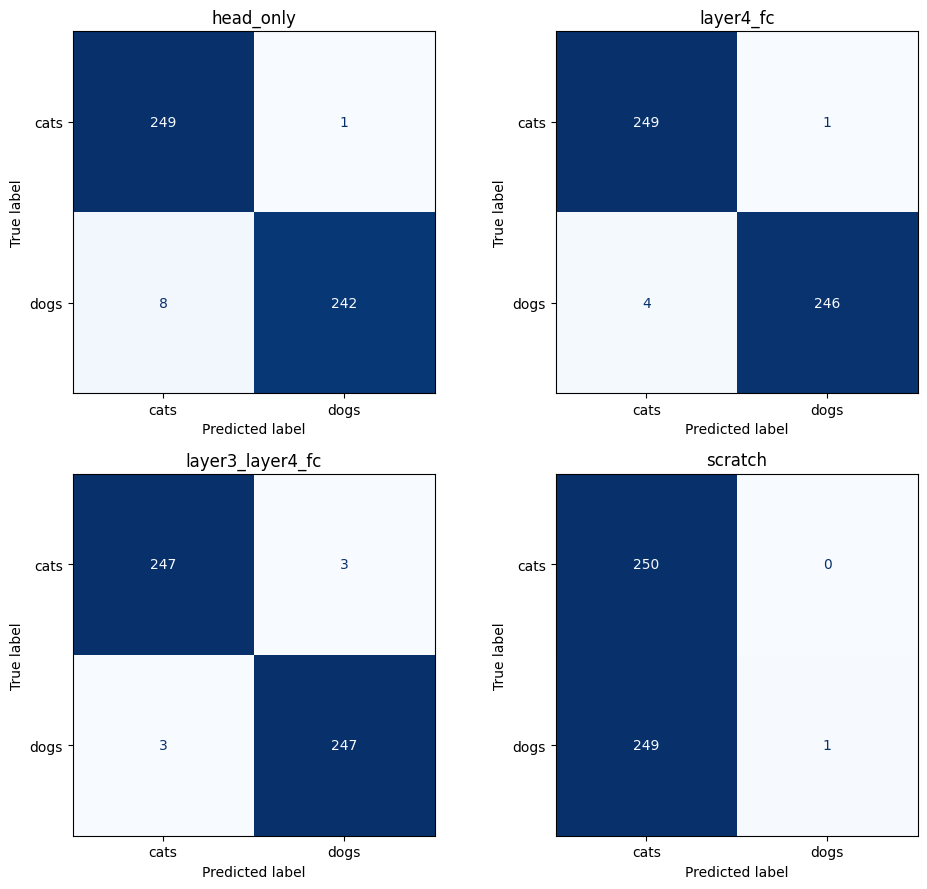

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, (model_name, (y_true, y_pred)) in zip(axes.ravel(), test_predictions.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        display_labels=class_names,
        cmap='Blues',
        colorbar=False,
        ax=ax,
    )
    ax.set_title(model_name)
plt.tight_layout()
plt.show()

confusion matrices confirm the previous results. `head_only` makes only 9 mistakes on 500 test images. `layer4_fc` makes 5 mistakes, and `layer3_layer4_fc` makes 6 mistakes, so the pretrained models classify both classes very well. The scratch model almost always predicts `cats`. It classifies all cats correctly, but almost all dogs are also predicted as cats. This explains why its accuracy is around `0.5` and why its F1 score is very low.

finally we inspect a few predictions of the best model

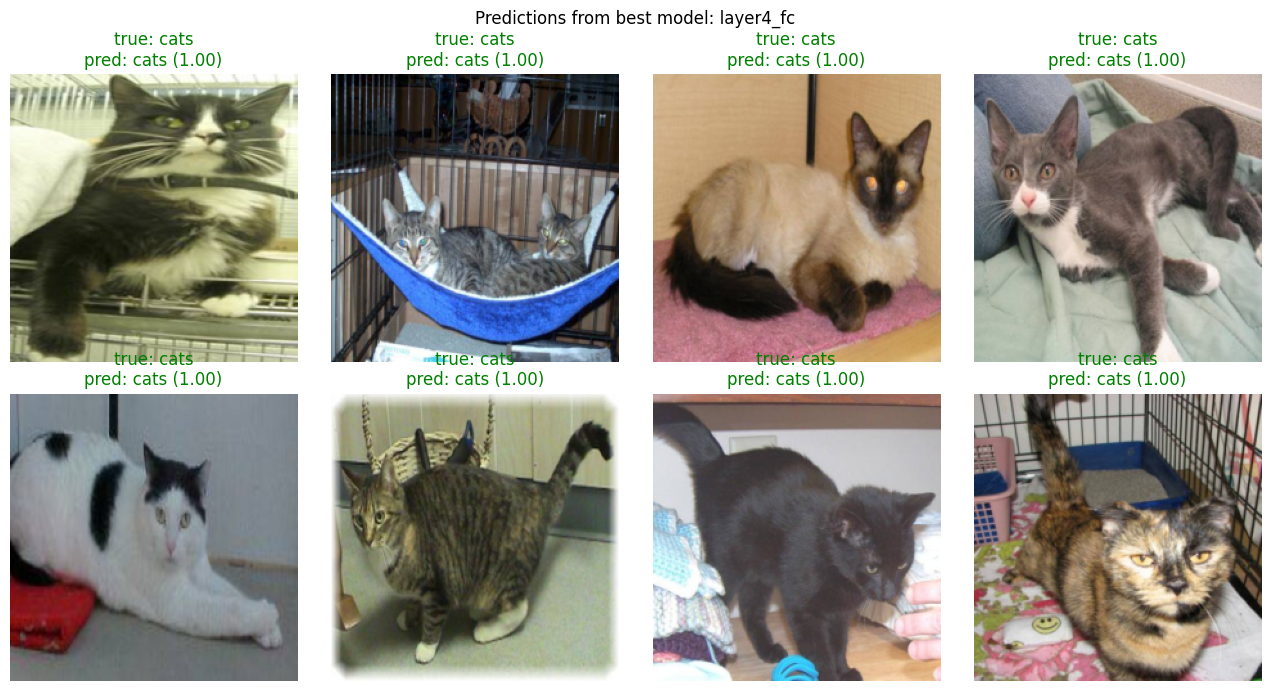

In [14]:
best_model = build_resnet50_model(best_model_config)
best_model.load_state_dict(best_model_state)
best_model.to(device)
best_model.eval()

def denormalize_image(tensor):
    image = tensor.detach().cpu().permute(1, 2, 0).numpy()
    image = image * np.array(imagenet_std) + np.array(imagenet_mean)
    return np.clip(image, 0, 1)

test_images, test_labels = next(iter(dataloaders['test']))
with torch.no_grad():
    logits = best_model(test_images.to(device))
    probs = torch.softmax(logits, dim=1).cpu()
    preds = probs.argmax(dim=1)

fig, axes = plt.subplots(2, 4, figsize=(13, 7))
for idx, ax in enumerate(axes.ravel()):
    image = denormalize_image(test_images[idx])
    true_label = class_names[test_labels[idx].item()]
    pred_label = class_names[preds[idx].item()]
    confidence = probs[idx, preds[idx]].item()
    color = 'green' if true_label == pred_label else 'red'

    ax.imshow(image)
    ax.set_title(f'true: {true_label}\npred: {pred_label} ({confidence:.2f})', color=color)
    ax.axis('off')

plt.suptitle(f'Predictions from best model: {best_model_config["name"]}')
plt.tight_layout()
plt.show()

del best_model

### Last test on our own photos

at the end lets try test on our own images. We use photos of Kefir, my cat, and Trufla, my friends dog. These images were not used in training, so it is a nice small sanity check outside the prepared dataset

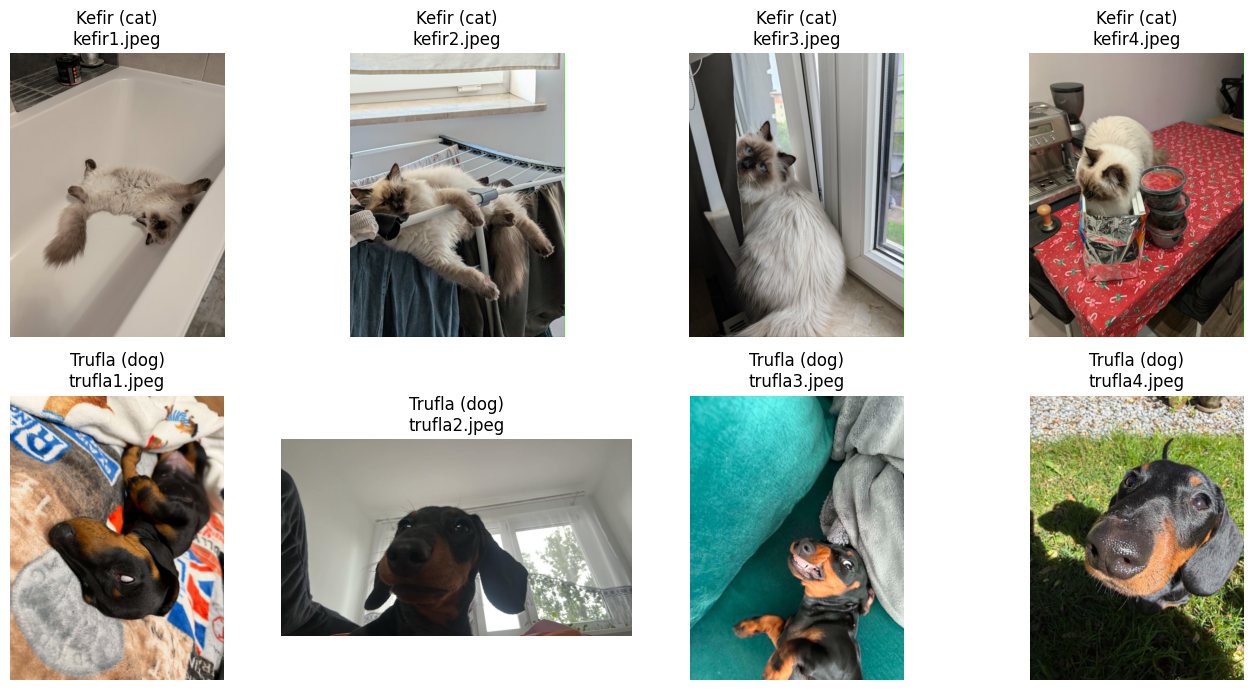

In [15]:
personal_root = Path('./../datasets/dogs-cats-images-personal')
personal_images = {
    'Kefir (cat)': sorted((personal_root / 'cat').glob('*')),
    'Trufla (dog)': sorted((personal_root / 'dog').glob('*')),
}

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for row_idx, (animal_name, image_paths) in enumerate(personal_images.items()):
    for col_idx, image_path in enumerate(image_paths[:4]):
        image = Image.open(image_path).convert('RGB')
        axes[row_idx, col_idx].imshow(image)
        axes[row_idx, col_idx].set_title(f'{animal_name}\n{image_path.name}')
        axes[row_idx, col_idx].axis('off')

plt.tight_layout()
plt.show()

lets run it

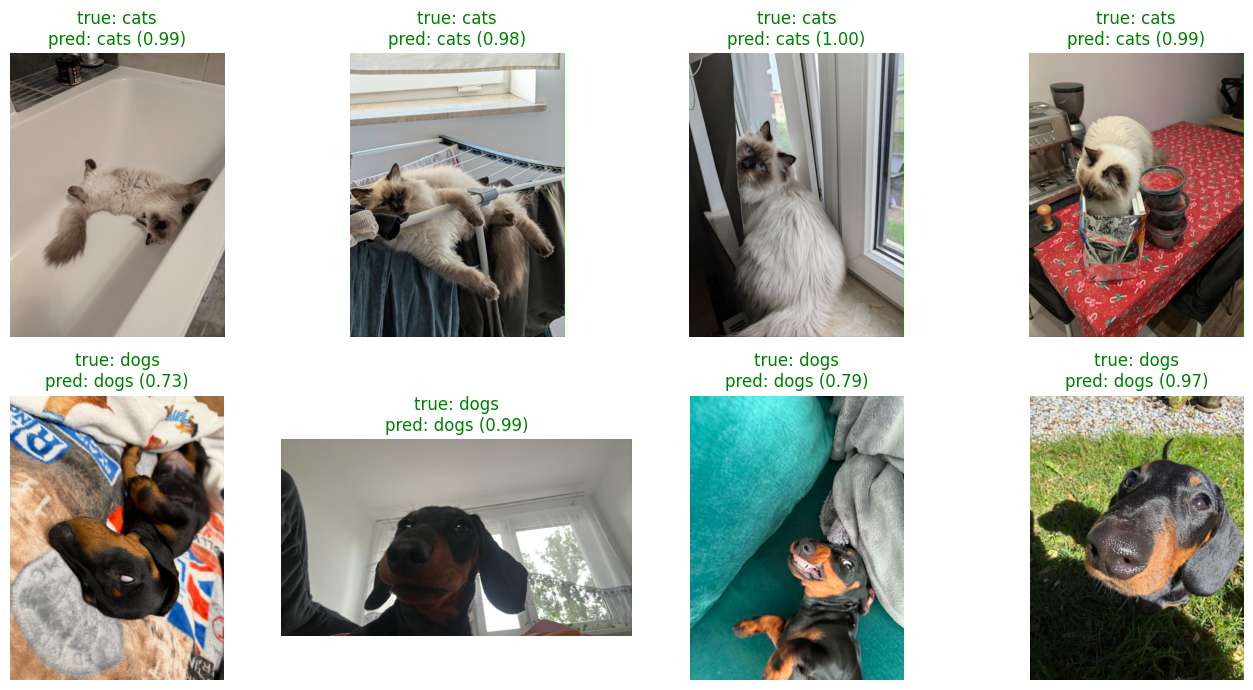

,image,true,predicted,confidence
0,kefir1.jpeg,cats,cats,0.995
1,kefir2.jpeg,cats,cats,0.984
2,kefir3.jpeg,cats,cats,0.998
3,kefir4.jpeg,cats,cats,0.995
4,trufla1.jpeg,dogs,dogs,0.726
5,trufla2.jpeg,dogs,dogs,0.989
6,trufla3.jpeg,dogs,dogs,0.788
7,trufla4.jpeg,dogs,dogs,0.972


In [16]:
personal_model = build_resnet50_model(best_model_config)
personal_model.load_state_dict(best_model_state)
personal_model.to(device)
personal_model.eval()

true_labels = {
    'Kefir (cat)': 'cats',
    'Trufla (dog)': 'dogs',
}

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
personal_results = []

for row_idx, (animal_name, image_paths) in enumerate(personal_images.items()):
    true_label = true_labels[animal_name]
    for col_idx, image_path in enumerate(image_paths[:4]):
        image = Image.open(image_path).convert('RGB')
        image_tensor = eval_transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            logits = personal_model(image_tensor)
            probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

        pred_idx = int(np.argmax(probs))
        pred_label = class_names[pred_idx]
        confidence = probs[pred_idx]
        color = 'green' if pred_label == true_label else 'red'

        personal_results.append({
            'image': image_path.name,
            'true': true_label,
            'predicted': pred_label,
            'confidence': round(float(confidence), 3),
        })

        axes[row_idx, col_idx].imshow(image)
        axes[row_idx, col_idx].set_title(
            f'true: {true_label}\npred: {pred_label} ({confidence:.2f})',
            color=color,
        )
        axes[row_idx, col_idx].axis('off')

plt.tight_layout()
plt.show()

display(pd.DataFrame(personal_results))
del personal_model

The personal test worked nicely. All 4 photos of Kefir were classified as `cats`, with very high confidence around `0.98-1.00`. Trufla was also classified correctly as `dogs` in all 4 photos, although two predictions had lower confidence, around `0.73` and `0.79`. this is not a formal evaluation, but it is a nice final check. The model did not only work on the prepared Kaggle split, but also on our own photos with different background, lighting and camera style.

### Conclusions

The results clearly show why transfer learning is useful here. Even the `head_only` model, where only 4098 parameters were trained, reached about `0.98` test accuracy. Fine-tuning later blocks improved the result a little bit. `layer4_fc` and `layer3_layer4_fc` both reached about `0.99` test accuracy. Their confusion matrices are also very clean: only around 5 mistakes on 500 test images. The difference between these two variants is small, so in practice `layer4_fc` is probably the best trade-off, because it trains fewer parameters than unfreezing both layer3 and layer4. Training ResNet50 from scratch worked much worse. It got only about `0.55` test accuracy and the confusion matrix shows a strong bias toward predicting `cats`.

Overall, the experiment confirms the main idea of transfer learning: with a small dataset, it is much better to start from a pretrained visual model and fine-tune only the classification head or the last blocks, instead of learning all visual features from zero. The personal photos at the end are not a benchmark, but they make a nice final sanity check. It shows how the trained model behaves on images outside the prepared Kaggle split.

## Problem 6.2: Few-Shot Learning

### Objective
Implement prototypical networks

### Tasks
- Use Omniglot or mini-ImageNet dataset.
- Implement 5-way 1-shot and 5-way 5-shot classification.
- Calculate episode-wise accuracy.
- Visualize embeddings using t-SNE.